# No-Arbitrage Pricing Relations

This notebook explores the main model-independent pricing relations from Module 3.

The goal is not to price options with a stochastic model yet.

Instead, we test no-arbitrage relationships for:

- forward pricing
- futures mark-to-market
- put-call parity

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Forward Pricing

A forward price is determined by no-arbitrage.

For a non-dividend-paying asset:

F = S × e^(rT)

If the asset pays dividends, the forward price is lower because the forward holder does not receive dividends before maturity.

In [3]:
def forward_no_dividends(S, r, T):
    return S * np.exp(r * T)


def forward_with_discrete_dividends(S, r, T, pv_dividends):
    return (S - pv_dividends) * np.exp(r * T)


def forward_with_dividend_yield(S, r, q, T):
    return S * np.exp((r - q) * T)


def currency_forward(S, r_domestic, r_foreign, T):
    return S * np.exp((r_domestic - r_foreign) * T)

In [4]:
S = 100
r = 0.05
T = 1
q = 0.02
pv_dividends = 3
r_foreign = 0.03

print("Forward without dividends:", round(forward_no_dividends(S, r, T), 2))
print("Forward with discrete dividends:", round(forward_with_discrete_dividends(S, r, T, pv_dividends), 2))
print("Forward with dividend yield:", round(forward_with_dividend_yield(S, r, q, T), 2))
print("Currency forward:", round(currency_forward(S, r, r_foreign, T), 2))

Forward without dividends: 105.13
Forward with discrete dividends: 101.97
Forward with dividend yield: 103.05
Currency forward: 102.02


## Interpretation

The forward price increases with the domestic risk-free rate.

The forward price decreases when the asset pays dividends or when the foreign interest rate is higher.

This happens because dividends or foreign interest are benefits of holding the asset before maturity.

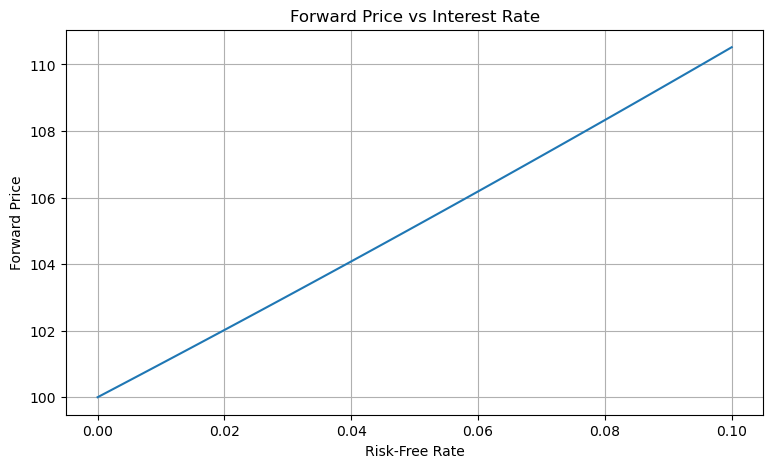

In [5]:
rates = np.linspace(0.00, 0.10, 100)

forward_prices = [
    forward_no_dividends(S, rate, T)
    for rate in rates
]

plt.figure(figsize=(9, 5))
plt.plot(rates, forward_prices)
plt.title("Forward Price vs Interest Rate")
plt.xlabel("Risk-Free Rate")
plt.ylabel("Forward Price")
plt.grid(True)
plt.show()

# 2. Forward Arbitrage Checker

If the market forward price differs from the theoretical no-arbitrage forward price, there may be an arbitrage opportunity.

If market forward > theoretical forward:

- forward is expensive
- buy the asset
- short the forward

If market forward < theoretical forward:

- forward is cheap
- short the asset
- long the forward

In [6]:
def check_forward_arbitrage(S, r, T, market_forward):
    theoretical_forward = forward_no_dividends(S, r, T)
    
    print(f"Theoretical forward price: {theoretical_forward:.2f}")
    print(f"Market forward price: {market_forward:.2f}")
    
    if market_forward > theoretical_forward:
        print("\nForward is expensive.")
        print("Arbitrage strategy:")
        print("- Borrow money")
        print("- Buy the underlying asset")
        print("- Short the forward contract")
        
    elif market_forward < theoretical_forward:
        print("\nForward is cheap.")
        print("Arbitrage strategy:")
        print("- Short sell the underlying asset")
        print("- Invest the proceeds at the risk-free rate")
        print("- Go long the forward contract")
        
    else:
        print("\nForward is fairly priced.")
        print("No arbitrage opportunity.")

In [7]:
S = 100
r = 0.05
T = 1

market_forward = 108

check_forward_arbitrage(S, r, T, market_forward)
market_forward = 102

check_forward_arbitrage(S, r, T, market_forward)

Theoretical forward price: 105.13
Market forward price: 108.00

Forward is expensive.
Arbitrage strategy:
- Borrow money
- Buy the underlying asset
- Short the forward contract
Theoretical forward price: 105.13
Market forward price: 102.00

Forward is cheap.
Arbitrage strategy:
- Short sell the underlying asset
- Invest the proceeds at the risk-free rate
- Go long the forward contract


# 3. Futures Mark-to-Market

A futures contract is marked to market daily.

This means that daily gains and losses are settled every day.

For a long futures position:

Daily P&L = F(t+1) - F(t)

The total P&L telescopes:

Total P&L = Final futures price - Initial futures price

In [8]:
futures_prices = np.array([100, 102, 101, 105, 103, 107])

daily_pnl = np.diff(futures_prices)
total_pnl = daily_pnl.sum()

print("Futures prices:", futures_prices)
print("Daily P&L:", daily_pnl)
print("Total P&L:", total_pnl)
print("Final price - initial price:", futures_prices[-1] - futures_prices[0])

Futures prices: [100 102 101 105 103 107]
Daily P&L: [ 2 -1  4 -2  4]
Total P&L: 7
Final price - initial price: 7


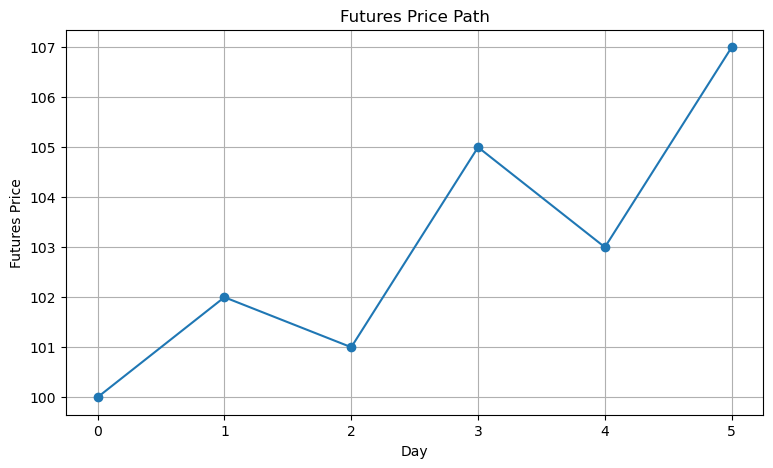

In [9]:
days = np.arange(len(futures_prices))

plt.figure(figsize=(9, 5))
plt.plot(days, futures_prices, marker="o")
plt.title("Futures Price Path")
plt.xlabel("Day")
plt.ylabel("Futures Price")
plt.grid(True)
plt.show()

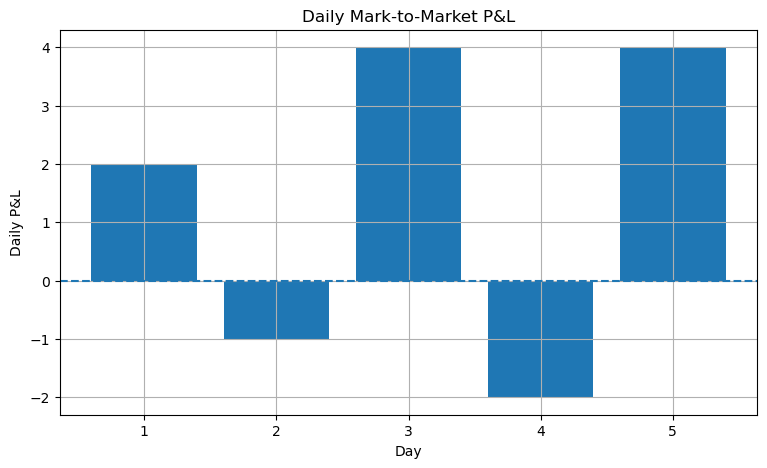

In [10]:
days_pnl = np.arange(1, len(futures_prices))

plt.figure(figsize=(9, 5))
plt.bar(days_pnl, daily_pnl)
plt.axhline(0, linestyle="--")
plt.title("Daily Mark-to-Market P&L")
plt.xlabel("Day")
plt.ylabel("Daily P&L")
plt.grid(True)
plt.show()

## Interpretation

The futures contract does not wait until maturity to settle gains and losses.

Instead, profits and losses are realized daily.

The total sum of daily P&L equals the final futures price minus the initial futures price.

# 4. Put-Call Parity Checker

For European options on a non-dividend-paying asset:

c + K e^(-rT) = p + S

where:

- c = European call price
- p = European put price
- S = current stock price
- K = strike price
- r = risk-free rate
- T = time to maturity

If the two sides are not equal, there may be arbitrage.

In [11]:
def check_put_call_parity(call_price, put_price, S, K, r, T):
    left_side = call_price + K * np.exp(-r * T)
    right_side = put_price + S
    
    print(f"Call + PV(K): {left_side:.2f}")
    print(f"Put + Stock: {right_side:.2f}")
    
    difference = left_side - right_side
    
    if abs(difference) < 1e-6:
        print("\nPut-call parity holds.")
        
    elif difference > 0:
        print("\nPut-call parity is violated.")
        print("Portfolio A is more expensive:")
        print("- Call + PV(K)")
        print("Portfolio B is cheaper:")
        print("- Put + Stock")
        print("Possible arbitrage idea:")
        print("- Sell Portfolio A")
        print("- Buy Portfolio B")
        
    else:
        print("\nPut-call parity is violated.")
        print("Portfolio B is more expensive:")
        print("- Put + Stock")
        print("Portfolio A is cheaper:")
        print("- Call + PV(K)")
        print("Possible arbitrage idea:")
        print("- Sell Portfolio B")
        print("- Buy Portfolio A")

In [12]:
S = 100
K = 100
r = 0.05
T = 1

call_price = 10
put_price = 5.12

check_put_call_parity(call_price, put_price, S, K, r, T)

call_price = 12
put_price = 5

check_put_call_parity(call_price, put_price, S, K, r, T)

Call + PV(K): 105.12
Put + Stock: 105.12

Put-call parity is violated.
Portfolio A is more expensive:
- Call + PV(K)
Portfolio B is cheaper:
- Put + Stock
Possible arbitrage idea:
- Sell Portfolio A
- Buy Portfolio B
Call + PV(K): 107.12
Put + Stock: 105.00

Put-call parity is violated.
Portfolio A is more expensive:
- Call + PV(K)
Portfolio B is cheaper:
- Put + Stock
Possible arbitrage idea:
- Sell Portfolio A
- Buy Portfolio B
